<a href="https://colab.research.google.com/github/BorgunKsenia/HW_DT_GB_CreditDefault/blob/main/HW_DT_GB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

print("\nTarget share:")
display(train["Credit Default"].value_counts(normalize=True))

print("\nMissing share (top 10):")
display(train.isna().mean().sort_values(ascending=False).head(10))

print("\nNumeric describe:")
display(train.select_dtypes(include=[np.number]).describe().T)

Train shape: (7500, 17)
Test shape: (2500, 16)


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10.0,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8.0,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6.0,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8.0,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0



Target share:


,proportion
Credit Default,
0,0.718267
1,0.281733



Missing share (top 10):


,0
Months since last delinquent,0.544133
Credit Score,0.207600
Annual Income,0.207600
Years in current job,0.049467
Bankruptcies,0.001867
Home Ownership,0.000000
Years of Credit History,0.000000
Number of Open Accounts,0.000000
Tax Liens,0.000000
Number of Credit Problems,0.000000



Numeric describe:


,count,mean,std,min,25%,50%,75%,max
Annual Income,5943.0,1.366392e+06,8.453392e+05,164597.0,844341.0,1168386.0,1640137.00,1.014934e+07
Years in current job,7129.0,5.919834e+00,3.557921e+00,0.5,3.0,6.0,10.00,1.000000e+01
Tax Liens,7500.0,3.013333e-02,2.716035e-01,0.0,0.0,0.0,0.00,7.000000e+00
Number of Open Accounts,7500.0,1.113093e+01,4.908924e+00,2.0,8.0,10.0,14.00,4.300000e+01
Years of Credit History,7500.0,1.831747e+01,7.041946e+00,4.0,13.5,17.0,21.80,5.770000e+01
Maximum Open Credit,7500.0,9.451537e+05,1.602622e+07,0.0,279229.5,478159.0,793501.50,1.304726e+09
Number of Credit Problems,7500.0,1.700000e-01,4.985978e-01,0.0,0.0,0.0,0.00,7.000000e+00
Months since last delinquent,3419.0,3.469260e+01,2.168881e+01,0.0,16.0,32.0,50.00,1.180000e+02
Bankruptcies,7486.0,1.171520e-01,3.471917e-01,0.0,0.0,0.0,0.00,4.000000e+00
Current Loan Amount,7500.0,1.187318e+07,3.192612e+07,11242.0,180169.0,309573.0,519882.00,1.000000e+08


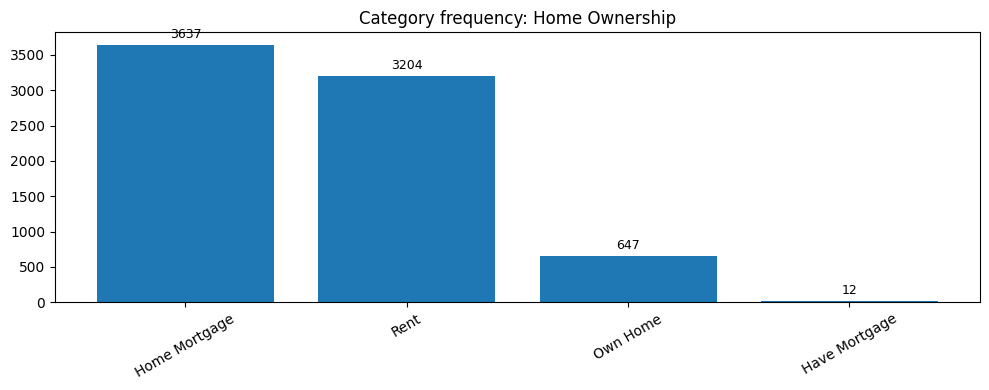

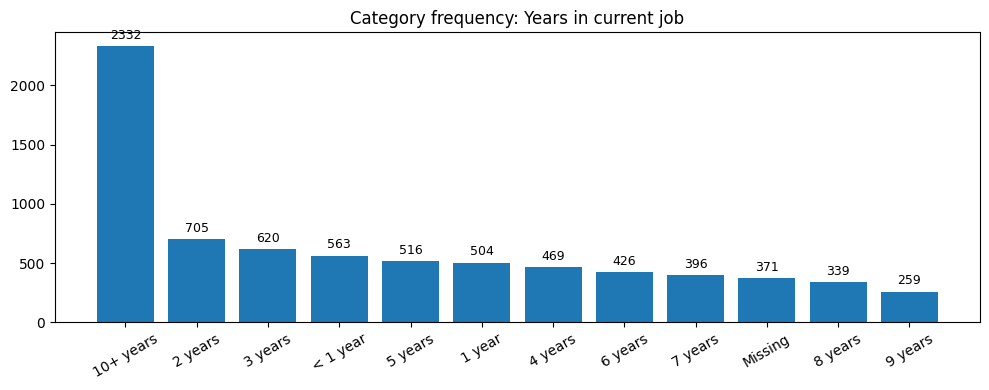

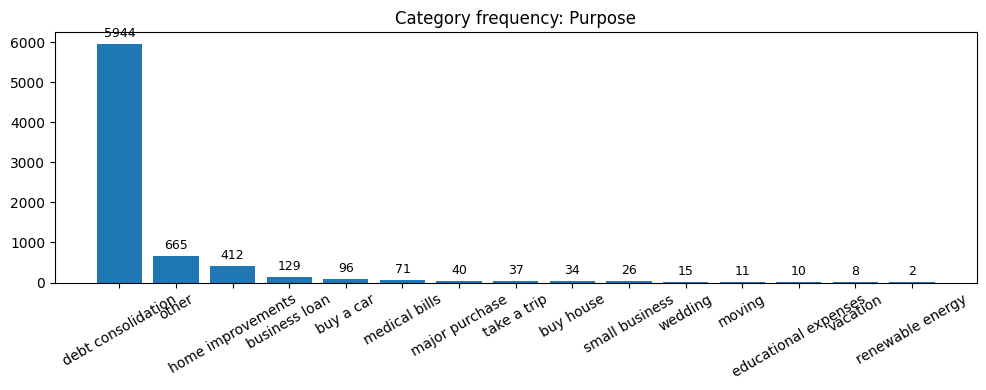

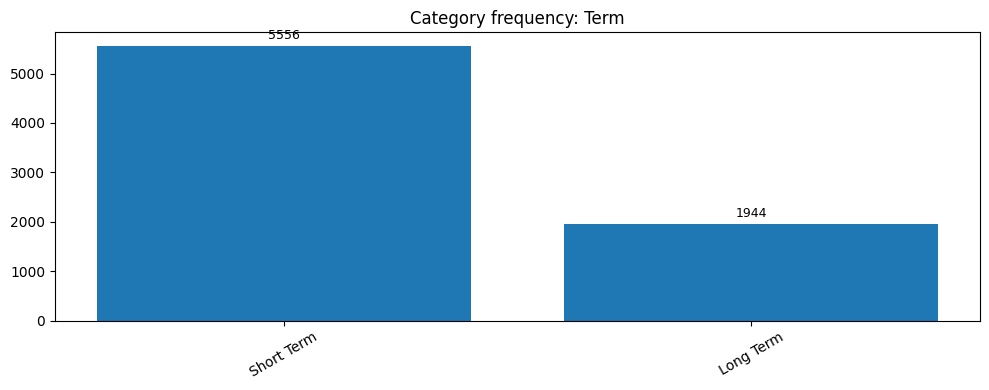

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# если train уже загружен — эту строку можно убрать
train = pd.read_csv("/content/course_project_train.csv")

cat_cols_eda = train.drop(columns=["Credit Default"]).select_dtypes(include="object").columns.tolist()

for col in cat_cols_eda:
    vc = train[col].fillna("Missing").value_counts()

    fig, ax = plt.subplots(figsize=(10,4))
    bars = ax.bar(vc.index.astype(str), vc.values)

    ax.set_title(f"Category frequency: {col}")
    ax.tick_params(axis="x", rotation=30)

    # метки значений над столбиками
    ax.bar_label(bars, labels=[str(int(v)) for v in vc.values], padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("/content/course_project_train.csv")

cat_cols_eda = train.drop(columns=["Credit Default"]).select_dtypes(include="object").columns.tolist()

for col in cat_cols_eda:
    vc = train[col].fillna("Missing").value_counts()
    plt.figure(figsize=(10,4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"Category frequency: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
cat_cols = train.drop(columns=["Credit Default"]).select_dtypes(include="object").columns.tolist()
num_cols = train.drop(columns=["Credit Default"]).select_dtypes(exclude="object").columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['Home Ownership', 'Purpose', 'Term']
Numeric: ['Annual Income', 'Years in current job', 'Tax Liens', 'Number of Open Accounts', 'Years of Credit History', 'Maximum Open Credit', 'Number of Credit Problems', 'Months since last delinquent', 'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance', 'Monthly Debt', 'Credit Score']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing
pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median", add_indicator=True), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), cat_cols)
    ],
    remainder="drop"
)

# Preprocessing для логрег
pre_log = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="median", add_indicator=True)),
            ("sc", StandardScaler(with_mean=False))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), cat_cols)
    ],
    remainder="drop"
)

print("Preprocessing objects created: pre, pre_log")

Preprocessing objects created: pre, pre_log


In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool


try:
    _ = pre_log
except NameError:
    cat_cols=[c for c in X_tr.columns if X_tr[c].dtype=="object"]
    num_cols=[c for c in X_tr.columns if c not in cat_cols]
    pre_log = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median", add_indicator=True)),
                ("sc", StandardScaler(with_mean=False))
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
            ]), cat_cols),
        ]
    )

# --- функция подбора порога
def best_thr_f1(y_true, proba, grid=300):
    qs=np.linspace(0.01,0.99,grid)
    thrs=np.unique(np.quantile(proba, qs))
    best_t=0.5; best_f=-1
    for t in thrs:
        f=f1_score(y_true, (proba>=t).astype(int), zero_division=0)
        if f>best_f:
            best_f=f; best_t=float(t)
    return best_t, float(best_f)

def eval_pipe(name, model):
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_val)[:,1]
    thr, f1 = best_thr_f1(y_val, p)
    auc = roc_auc_score(y_val, p)
    return {"Model": name, "F1": f1, "AUC": auc, "Gini": 2*auc-1, "Best_thr": thr}


models = []

# 1) Logistic Regression
models.append(("LogReg", Pipeline([("pre", pre_log),
                                  ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))])))

# 2) Decision Tree
models.append(("DecisionTree", Pipeline([("pre", pre),
                                        ("clf", DecisionTreeClassifier(
                                            max_depth=6, min_samples_leaf=30,
                                            class_weight="balanced", random_state=42
                                        ))])))

# 3) Random Forest (ансамбль деревьев)
models.append(("RandomForest", Pipeline([("pre", pre),
                                        ("clf", RandomForestClassifier(
                                            n_estimators=400,
                                            min_samples_leaf=4,
                                            class_weight="balanced_subsample",
                                            random_state=42,
                                            n_jobs=-1
                                        ))])))


models.append(("ExtraTrees", Pipeline([("pre", pre),
                                      ("clf", ExtraTreesClassifier(
                                          n_estimators=500,
                                          min_samples_leaf=3,
                                          class_weight="balanced",
                                          random_state=42,
                                          n_jobs=-1
                                      ))])))

# 4) Gradient Boosting family: LightGBM / XGBoost / CatBoost
models.append(("LightGBM", Pipeline([("pre", pre),
                                    ("clf", lgb.LGBMClassifier(
                                        n_estimators=700, learning_rate=0.04, num_leaves=31,
                                        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                        random_state=42, class_weight="balanced"
                                    ))])))

scale_pos = ( (y_tr==0).sum() / (y_tr==1).sum() )
models.append(("XGBoost", Pipeline([("pre", pre),
                                   ("clf", xgb.XGBClassifier(
                                       n_estimators=900, learning_rate=0.03, max_depth=5,
                                       subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                       min_child_weight=2,
                                       objective="binary:logistic",
                                       eval_metric="logloss",
                                       random_state=42, n_jobs=-1,
                                       scale_pos_weight=float(scale_pos)
                                   ))])))

# CatBoost отдельно (native categorical)
cat_cols=[c for c in X_tr.columns if X_tr[c].dtype=="object"]
def eval_catboost():
    Xtr_cb=X_tr.copy(); Xvl_cb=X_val.copy()
    for c in cat_cols:
        Xtr_cb[c]=Xtr_cb[c].astype(str).fillna("missing")
        Xvl_cb[c]=Xvl_cb[c].astype(str).fillna("missing")
    cat_idx=[Xtr_cb.columns.get_loc(c) for c in cat_cols]
    pos_w = ((y_tr==0).sum() / (y_tr==1).sum())
    cb = CatBoostClassifier(
        iterations=2000, learning_rate=0.03, depth=6,
        loss_function="Logloss", random_seed=42, verbose=False,
        class_weights=[1.0, float(pos_w)],
        od_type="Iter", od_wait=80
    )
    cb.fit(Pool(Xtr_cb, y_tr, cat_features=cat_idx),
           eval_set=Pool(Xvl_cb, y_val, cat_features=cat_idx),
           use_best_model=True)
    p = cb.predict_proba(Xvl_cb)[:,1]
    thr, f1 = best_thr_f1(y_val, p)
    auc = roc_auc_score(y_val, p)
    return {"Model":"CatBoost", "F1":f1, "AUC":auc, "Gini":2*auc-1, "Best_thr":thr}

rows=[]
for name, mdl in models:
    rows.append(eval_pipe(name, mdl))
rows.append(eval_catboost())

box_full = pd.DataFrame(rows).sort_values("F1", ascending=False)
display(box_full)

[LightGBM] [Info] Number of positive: 1690, number of negative: 4310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1915
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,F1,AUC,Gini,Best_thr
6,CatBoost,0.556117,0.764507,0.529013,0.497610
2,RandomForest,0.549232,0.765628,0.531256,0.378441
0,LogReg,0.547710,0.760569,0.521137,0.488040
3,ExtraTrees,0.545607,0.756934,0.513867,0.418635
4,LightGBM,0.533333,0.749802,0.499604,0.469511
5,XGBoost,0.532520,0.746915,0.493831,0.447282
1,DecisionTree,0.526208,0.743532,0.487063,0.505647


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

# -----------------------------
# 0) Берем матрицы признаков через preprocessor
# -----------------------------

Xtr = pre.fit_transform(X_tr)
Xvl = pre.transform(X_val)


if hasattr(Xtr, "toarray"):
    Xtr = Xtr.toarray()
if hasattr(Xvl, "toarray"):
    Xvl = Xvl.toarray()

ytr = np.asarray(y_tr).astype(int)
yvl = np.asarray(y_val).astype(int)

def best_thr_f1(y_true, proba, grid=300):
    qs = np.linspace(0.01, 0.99, grid)
    thrs = np.unique(np.quantile(proba, qs))
    best_t, best_f = 0.5, -1
    for t in thrs:
        f = f1_score(y_true, (proba >= t).astype(int), zero_division=0)
        if f > best_f:
            best_f = f
            best_t = float(t)
    return best_t, float(best_f)

def eval_model(name, proba, y_true):
    thr, f1 = best_thr_f1(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    return {"Model": name, "F1": f1, "AUC": auc, "Gini": gini, "Best_thr": thr}

# -----------------------------
# 1) Самописное CART (Gini), бинарная классификация
# -----------------------------
class SimpleCART:
    class Node:
        __slots__ = ("is_leaf", "prob1", "f", "thr", "left", "right")
        def __init__(self, is_leaf, prob1, f=None, thr=None, left=None, right=None):
            self.is_leaf = is_leaf
            self.prob1 = prob1
            self.f = f
            self.thr = thr
            self.left = left
            self.right = right

    def __init__(self, max_depth=4, min_samples_split=40, min_samples_leaf=20, n_thresholds=25, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.rng = np.random.default_rng(random_state)
        self.root = None

    @staticmethod
    def _gini(y):
        if y.size == 0: return 0.0
        p = y.mean()
        return 2 * p * (1 - p)

    def _best_split(self, X, y):
        n, m = X.shape
        if n < self.min_samples_split:
            return None

        parent_gini = self._gini(y)
        if parent_gini == 0:
            return None

        best = None
        best_gain = 0.0

        # Перебор признаков
        for f in range(m):
            col = X[:, f]
            if np.all(col == col[0]):
                continue


            qs = np.linspace(0.05, 0.95, self.n_thresholds)
            thrs = np.unique(np.quantile(col, qs))
            for thr in thrs:
                left = col <= thr
                nl = left.sum()
                nr = n - nl
                if nl < self.min_samples_leaf or nr < self.min_samples_leaf:
                    continue

                gl = self._gini(y[left])
                gr = self._gini(y[~left])
                weighted = (nl / n) * gl + (nr / n) * gr
                gain = parent_gini - weighted

                if gain > best_gain:
                    best_gain = gain
                    best = (f, float(thr), left)

        return best  # (feature, thr, mask)

    def _build(self, X, y, depth):
        prob1 = float(y.mean()) if y.size else 0.0

        # stopping
        if depth >= self.max_depth or y.size < self.min_samples_split or self._gini(y) == 0:
            return self.Node(is_leaf=True, prob1=prob1)

        split = self._best_split(X, y)
        if split is None:
            return self.Node(is_leaf=True, prob1=prob1)

        f, thr, mask = split
        left = self._build(X[mask], y[mask], depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)

        return self.Node(is_leaf=False, prob1=prob1, f=f, thr=thr, left=left, right=right)

    def fit(self, X, y):
        self.root = self._build(X, y, 0)
        return self

    def _predict_one(self, x, node):
        while not node.is_leaf:
            node = node.left if x[node.f] <= node.thr else node.right
        return node.prob1

    def predict_proba(self, X):
        p = np.array([self._predict_one(x, self.root) for x in X], dtype=float)
        # sklearn-style: [:,1]
        return np.c_[1 - p, p]

# -----------------------------
# 2) Самописный Random Forest = bagging SimpleCART
# -----------------------------
class SimpleRF:
    def __init__(self, n_estimators=40, max_depth=4, min_samples_split=40, min_samples_leaf=20,
                 n_thresholds=25, max_features="sqrt", random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.n_thresholds = n_thresholds
        self.max_features = max_features
        self.rng = np.random.default_rng(random_state)
        self.trees = []
        self.feature_subsets = []

    def _choose_features(self, m):
        if self.max_features == "sqrt":
            k = max(1, int(np.sqrt(m)))
        elif self.max_features == "log2":
            k = max(1, int(np.log2(m)))
        elif isinstance(self.max_features, int):
            k = max(1, min(m, self.max_features))
        else:
            k = m
        return self.rng.choice(m, size=k, replace=False)

    def fit(self, X, y):
        n, m = X.shape
        self.trees = []
        self.feature_subsets = []

        for i in range(self.n_estimators):
            idx = self.rng.integers(0, n, size=n)  # bootstrap
            feats = self._choose_features(m)

            tree = SimpleCART(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                n_thresholds=self.n_thresholds,
                random_state=int(self.rng.integers(0, 1_000_000))
            )
            tree.fit(X[idx][:, feats], y[idx])

            self.trees.append(tree)
            self.feature_subsets.append(feats)

        return self

    def predict_proba(self, X):
        probs = []
        for tree, feats in zip(self.trees, self.feature_subsets):
            probs.append(tree.predict_proba(X[:, feats])[:, 1])
        p = np.mean(np.vstack(probs), axis=0)
        return np.c_[1 - p, p]

# -----------------------------
# 3) Самописный Gradient Boosting (логистическая функция)
# -----------------------------
class SimpleGBStumps:
    def __init__(self, n_estimators=200, learning_rate=0.1, reg_lambda=1.0, n_thresholds=25, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.reg_lambda = reg_lambda
        self.n_thresholds = n_thresholds
        self.rng = np.random.default_rng(random_state)
        self.base_score = 0.0
        self.stumps = []  # (f, thr, w_left, w_right)

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def _best_stump(self, X, grad, hess):
        n, m = X.shape
        best_gain = 0.0
        best = None

        G = grad.sum()
        H = hess.sum()
        # формула gain: 0.5 * (G_L^2/(H_L+λ) + G_R^2/(H_R+λ) - G^2/(H+λ))
        denom_parent = (H + self.reg_lambda)

        for f in range(m):
            col = X[:, f]
            if np.all(col == col[0]):
                continue
            qs = np.linspace(0.05, 0.95, self.n_thresholds)
            thrs = np.unique(np.quantile(col, qs))

            for thr in thrs:
                left = col <= thr
                if left.sum() == 0 or left.sum() == n:
                    continue

                GL = grad[left].sum()
                HL = hess[left].sum()
                GR = G - GL
                HR = H - HL

                gain = 0.5 * (
                    (GL * GL) / (HL + self.reg_lambda)
                    + (GR * GR) / (HR + self.reg_lambda)
                    - (G * G) / denom_parent
                )
                if gain > best_gain:
                    best_gain = gain
                    best = (f, float(thr), left, GL, HL, GR, HR)

        if best is None:
            return None

        f, thr, left, GL, HL, GR, HR = best
        wL = - GL / (HL + self.reg_lambda)
        wR = - GR / (HR + self.reg_lambda)
        return (f, thr, float(wL), float(wR))

    def fit(self, X, y):
        y = y.astype(float)
        p0 = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.base_score = float(np.log(p0 / (1 - p0)))
        self.stumps = []
        F = np.full(X.shape[0], self.base_score, dtype=float)

        for t in range(self.n_estimators):
            p = self._sigmoid(F)
            grad = (p - y)                 # dL/dF
            hess = (p * (1 - p))           # d2L/dF2

            stump = self._best_stump(X, grad, hess)
            if stump is None:
                break

            f, thr, wL, wR = stump
            self.stumps.append(stump)

            # update
            mask = X[:, f] <= thr
            F[mask] += self.learning_rate * wL
            F[~mask] += self.learning_rate * wR

        return self

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.base_score, dtype=float)
        for f, thr, wL, wR in self.stumps:
            mask = X[:, f] <= thr
            F[mask] += self.learning_rate * wL
            F[~mask] += self.learning_rate * wR
        p = self._sigmoid(F)
        return np.c_[1 - p, p]

# -----------------------------
# 4) Обучаем и сравниваем
# -----------------------------
cart = SimpleCART(max_depth=4, min_samples_split=60, min_samples_leaf=30, n_thresholds=25)
rf   = SimpleRF(n_estimators=50, max_depth=4, min_samples_split=60, min_samples_leaf=30, n_thresholds=25, max_features="sqrt")
gb   = SimpleGBStumps(n_estimators=250, learning_rate=0.12, reg_lambda=1.0, n_thresholds=25)

cart.fit(Xtr, ytr)
rf.fit(Xtr, ytr)
gb.fit(Xtr, ytr)

proba_cart = cart.predict_proba(Xvl)[:, 1]
proba_rf   = rf.predict_proba(Xvl)[:, 1]
proba_gb   = gb.predict_proba(Xvl)[:, 1]

rows = []
rows.append(eval_model("HAND_CART", proba_cart, yvl))
rows.append(eval_model("HAND_RF", proba_rf, yvl))
rows.append(eval_model("HAND_GB_Stumps", proba_gb, yvl))

hand_res = pd.DataFrame(rows).sort_values("F1", ascending=False)
display(hand_res)

print("Готово: самописные модели обучены и оценены на validation.")

,Model,F1,AUC,Gini,Best_thr
2,HAND_GB_Stumps,0.553435,0.760462,0.520924,0.281092
1,HAND_RF,0.543517,0.756984,0.513968,0.279646
0,HAND_CART,0.511243,0.729340,0.458679,0.369981


Готово: самописные модели обучены и оценены на validation.


In [ ]:
all_models = pd.concat([box_full, hand_res], ignore_index=True).sort_values("F1", ascending=False)
display(all_models)

,Model,F1,AUC,Gini,Best_thr
0,CatBoost,0.556117,0.764507,0.529013,0.497610
7,HAND_GB_Stumps,0.553435,0.760462,0.520924,0.281092
1,RandomForest,0.549232,0.765628,0.531256,0.378441
2,LogReg,0.547710,0.760569,0.521137,0.488040
3,ExtraTrees,0.545607,0.756934,0.513867,0.418635
8,HAND_RF,0.543517,0.756984,0.513968,0.279646
4,LightGBM,0.533333,0.749802,0.499604,0.469511
5,XGBoost,0.532520,0.746915,0.493831,0.447282
6,DecisionTree,0.526208,0.743532,0.487063,0.505647
9,HAND_CART,0.511243,0.729340,0.458679,0.369981


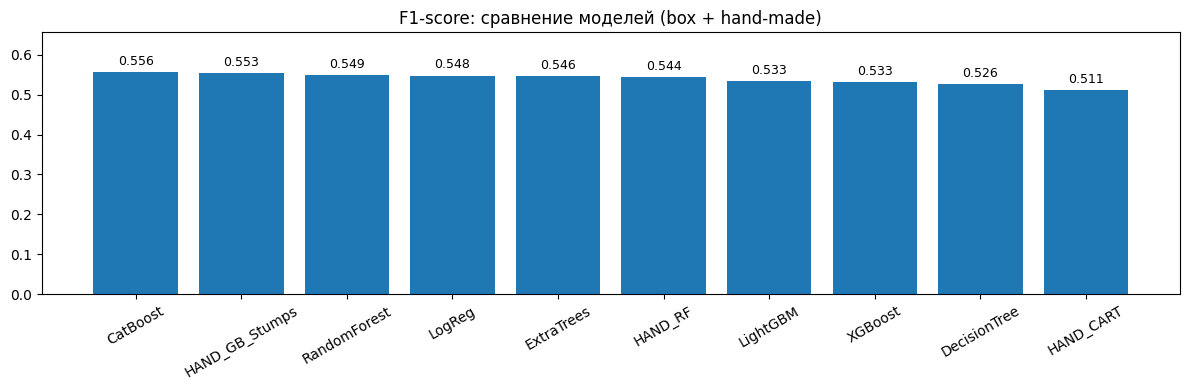

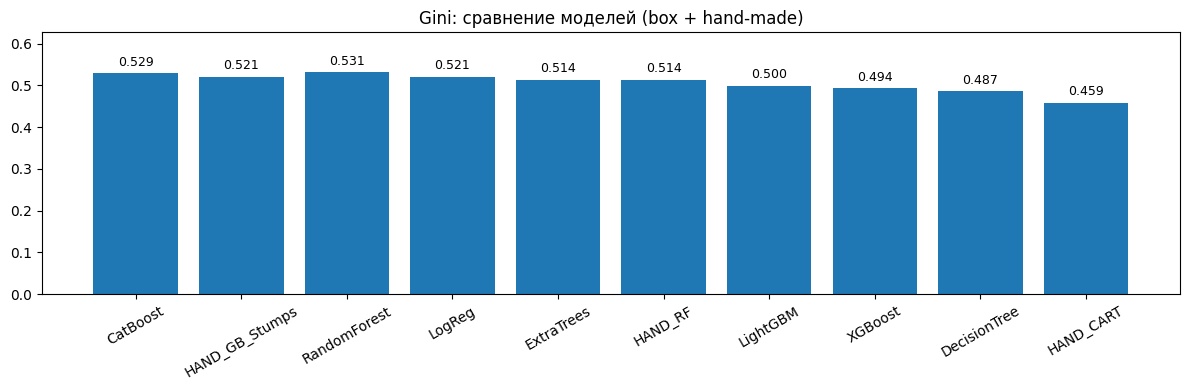

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Собираем ВСЕ модели:
all_res = pd.concat(
    [
        box_full[["Model", "F1", "Gini"]].copy(),
        hand_res[["Model", "F1", "Gini"]].copy()
    ],
    ignore_index=True
).sort_values("F1", ascending=False)

def plot_bar_with_labels(df, metric, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(df["Model"], df[metric])
    ax.set_title(title)
    ax.set_ylim(0, df[metric].max() * 1.18)
    ax.tick_params(axis="x", rotation=30)

    # метки значений
    ax.bar_label(
        bars,
        labels=[f"{v:.3f}" for v in df[metric].values],
        padding=3,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

plot_bar_with_labels(all_res, "F1",   "F1-score: сравнение моделей (box + hand-made)")
plot_bar_with_labels(all_res, "Gini", "Gini: сравнение моделей (box + hand-made)")

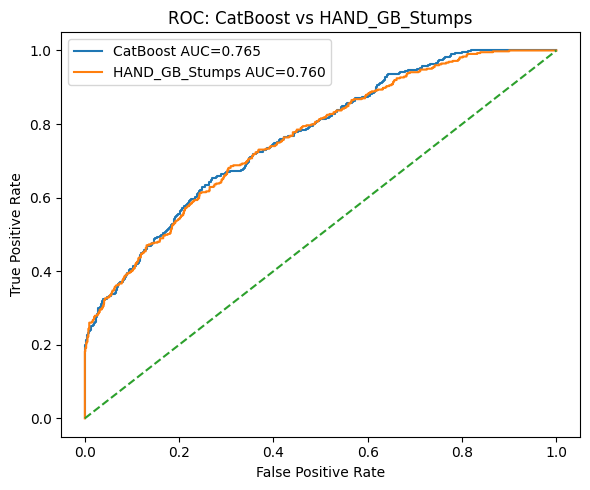

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr1, tpr1, _ = roc_curve(yvl, proba_cat_val)
fpr2, tpr2, _ = roc_curve(yvl, proba_hand_gb)

plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label=f"CatBoost AUC={auc(fpr1,tpr1):.3f}")
plt.plot(fpr2, tpr2, label=f"HAND_GB_Stumps AUC={auc(fpr2,tpr2):.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC: CatBoost vs HAND_GB_Stumps")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

CatBoost лучший по** F1=0.556, Gini=0.529**

лучший самописный HAND_GB_Stumps F1=0.553, Gini=0.521

ROC близкие, самописный GB адекватный

Порог подбирался по F1 на validation

DecisionTree (numeric-only) | F1@0.5=0.517 | AUC=0.709 | Gini=0.419


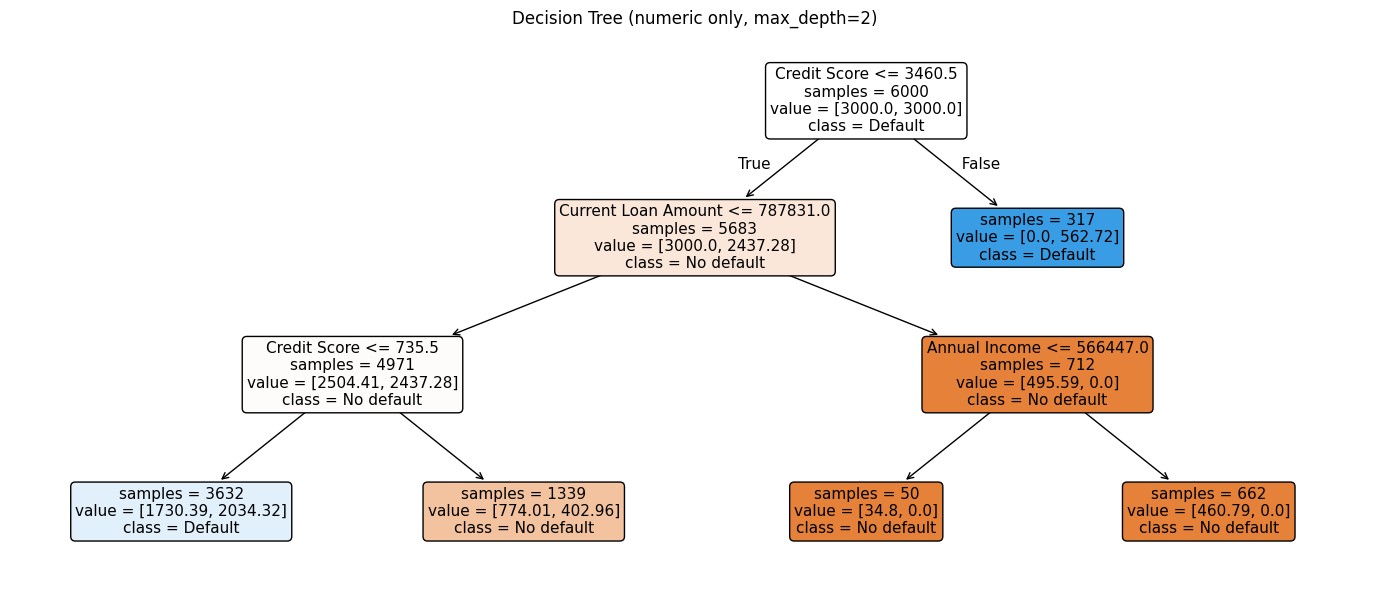

In [ ]:
# Decision Tree visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, roc_auc_score


Xtr_num = X_tr.select_dtypes(include=[np.number]).copy()
Xvl_num = X_val.select_dtypes(include=[np.number]).copy()

ytr = y_tr.values.astype(int)
yvl = y_val.values.astype(int)


imp = SimpleImputer(strategy="median")
Xtr_num_imp = imp.fit_transform(Xtr_num)
Xvl_num_imp = imp.transform(Xvl_num)


dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)
dt.fit(Xtr_num_imp, ytr)


proba = dt.predict_proba(Xvl_num_imp)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(yvl, proba)
gini = 2 * auc - 1
f1 = f1_score(yvl, pred, zero_division=0)

print(f"DecisionTree (numeric-only) | F1@0.5={f1:.3f} | AUC={auc:.3f} | Gini={gini:.3f}")

# 5) Plot the tree nicely
plt.figure(figsize=(14, 6))
plot_tree(
    dt,
    feature_names=Xtr_num.columns.tolist(),
    class_names=["No default", "Default"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=11
)
plt.title("Decision Tree (numeric only, max_depth=2)")
plt.tight_layout()
plt.show()